# Lecture 3: Joint Capacity and Dispatch Optimisation
**DTU Course 46770 — Integrated Energy Grids** | February 2026

---
This notebook solves **Problems 3.1 and 3.2**: joint optimisation of generation capacity and hourly dispatch for Portugal (2015), using a linear programme (LP) solved via [PyPSA](https://pypsa.org).

| Problem | Scope |
|---------|-------|
| **3.1a–b** | Wind + Solar PV + OCGT · no storage |
| **3.1c–e** | + Battery storage + existing CCGT (6 GW) |
| **3.2**   | Wind + Solar PV + OCGT + Battery · no CCGT |

In [106]:
import os
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Change to project root
os.chdir(r'c:\Users\User\OneDrive\Documents\DTU\46770 - Integrated energy grids\DTU-Course---Integrated-Energy-Grids')
print('Working directory:', os.getcwd())

Working directory: c:\Users\User\OneDrive\Documents\DTU\46770 - Integrated energy grids\DTU-Course---Integrated-Energy-Grids


## 1  Imports, Colour Palette & Global Style

In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import pypsa

# ── Navy / Blue colour palette ───────────────────────────────────────────────
C = {
    'wind':     '#1e3a8a',   # deep navy blue   – onshore wind
    'solar':    "#e7cf19",   # royal blue        – solar PV
    'ocgt':     "#09ec64",   # light sky-blue    – OCGT (peaker)
    'ccgt':     "#01751a",   # midnight blue     – CCGT (combined-cycle)
    'battery':  "#021720",   # cyan-blue         – battery (discharge)
    'bat_chg':  "#0865d6",   # pale blue         – battery charging area
    'demand':   '#dc2626',   # crimson red       – demand curve (contrast)
    'price':    "#ff8800",   # amber             – electricity price
    'bg':       "#dbebff",   # very pale blue    – axes background
}

# ── Global matplotlib style ──────────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize':    (12, 4.5),
    'figure.dpi':        120,
    'figure.facecolor':  'white',
    'axes.facecolor':    C['bg'],
    'axes.edgecolor':    '#94a3b8',
    'axes.linewidth':    0.8,
    'axes.grid':         True,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlepad':     10,
    'axes.labelsize':    11,
    'axes.labelpad':     6,
    'grid.color':        '#cbd5e1',
    'grid.linewidth':    0.6,
    'grid.alpha':        0.9,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'legend.framealpha': 0.92,
    'legend.edgecolor':  '#94a3b8',
    'lines.linewidth':   1.8,
    'font.family':       'sans-serif',
    'font.size':         11,
})

print('Imports ready. Navy/blue palette loaded.')
print('Technologies:', list(C.keys()))

Imports ready. Navy/blue palette loaded.
Technologies: ['wind', 'solar', 'ocgt', 'ccgt', 'battery', 'bat_chg', 'demand', 'price', 'bg']


## 2  Data Loading & Preprocessing
Capacity-factor time series for Portugal (`PRT`) are taken from:
- **Onshore wind**: [zenodo.org/record/3253876](https://zenodo.org/record/3253876)
- **Solar PV** (optimal tilt): [zenodo.org/record/2613651](https://zenodo.org/record/2613651)
- **Electricity demand**: [GitHub aleks-g/integrated-energy-grids](https://github.com/aleks-g/integrated-energy-grids)

We use **Portugal 2015** (8 760 hourly snapshots).

In [108]:
COUNTRY = 'PRT'   # Portugal (ISO 3166-1 alpha-3 in these datasets)
YEAR    = 2015

# Load raw CSV files
wind_raw   = pd.read_csv('data/onshore_wind_1979-2017.csv', sep=';', index_col=0, parse_dates=True)
pv_raw     = pd.read_csv('data/pv_optimal.csv',             sep=';', index_col=0, parse_dates=True)
demand_raw = pd.read_csv('data/electricity_demand.csv',     sep=';', index_col=0, parse_dates=True)

# ── Filter for Portugal, year 2015 → numpy arrays ────────────────────────────
# (using .values avoids timezone-alignment issues with PyPSA snapshots)
mask = wind_raw.index.year == YEAR
cf_wind  = wind_raw.loc[mask,  COUNTRY].values   # capacity factors, shape (8760,)
cf_solar = pv_raw.loc[mask,    COUNTRY].values
demand   = demand_raw[COUNTRY].values            # MW, already 2015 only

# ── Sanity checks ────────────────────────────────────────────────────────────
assert len(cf_wind) == 8760,  f'Expected 8760 wind hours, got {len(cf_wind)}'
assert len(cf_solar) == 8760, f'Expected 8760 solar hours, got {len(cf_solar)}'
assert len(demand)  == 8760,  f'Expected 8760 demand hours, got {len(demand)}'

# UTC time index for PyPSA (timezone-naive)
snapshots = pd.date_range('2015-01-01', periods=8760, freq='h')

print(f'Data ready — {COUNTRY}, {YEAR}  ({len(demand)} hourly snapshots)')
print(f'  Wind CF  : mean={cf_wind.mean():.3f}  max={cf_wind.max():.3f}')
print(f'  Solar CF : mean={cf_solar.mean():.3f}  max={cf_solar.max():.3f}')
print(f'  Demand   : mean={demand.mean():.0f} MW  '
      f'min={demand.min():.0f} MW  max={demand.max():.0f} MW')
print(f'  Annual demand : {demand.sum()/1e6:.2f} TWh')

KeyboardInterrupt: 

### Input data overview — January 2015

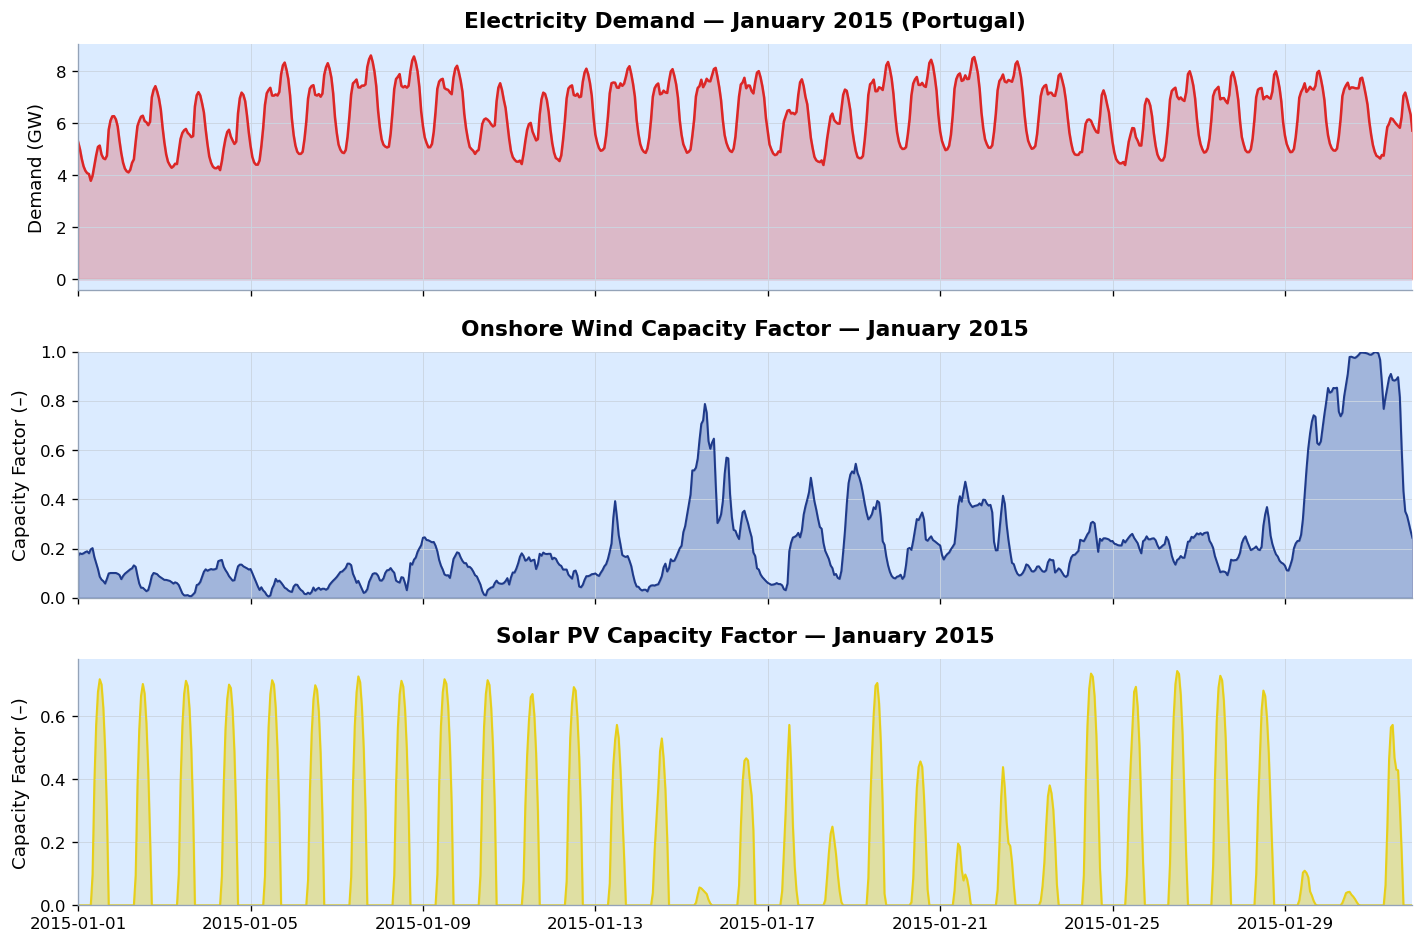

Observation: demand peaks in morning/evening; wind is highly variable; solar shows clear daily cycles with peak around midday.


In [ ]:
jan = slice(0, 744)   # first 744 hours = January 2015
ts  = snapshots[jan]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Demand
axes[0].fill_between(ts, demand[jan]/1e3, alpha=0.25, color=C['demand'])
axes[0].plot(ts, demand[jan]/1e3, color=C['demand'], lw=1.5)
axes[0].set_ylabel('Demand (GW)')
axes[0].set_title('Electricity Demand — January 2015 (Portugal)')

# Wind
axes[1].fill_between(ts, cf_wind[jan], alpha=0.3, color=C['wind'])
axes[1].plot(ts, cf_wind[jan], color=C['wind'], lw=1.2)
axes[1].set_ylabel('Capacity Factor (–)')
axes[1].set_title('Onshore Wind Capacity Factor — January 2015')
axes[1].set_ylim(0, 1.0)

# Solar
axes[2].fill_between(ts, cf_solar[jan], alpha=0.4, color=C['solar'])
axes[2].plot(ts, cf_solar[jan], color=C['solar'], lw=1.2)
axes[2].set_ylabel('Capacity Factor (–)')
axes[2].set_title('Solar PV Capacity Factor — January 2015')
axes[2].set_ylim(0, None)

for ax in axes:
    ax.set_xlim(ts[0], ts[-1])

plt.tight_layout()
plt.show()
print('Observation: demand peaks in morning/evening; wind is highly variable;'
      ' solar shows clear daily cycles with peak around midday.')

---
## Problem 3.1 — Wind · Solar PV · OCGT System

### Cost Assumptions

| Technology | Capital cost (EUR/MW/a) | Marginal cost (EUR/MWh) | Efficiency |
|------------|------------------------|--------------------------|------------|
| Onshore wind | 101 644 | 0 | — |
| Solar PV     |  51 346 | 0 | — |
| OCGT         |  47 718 | 64.7 | 0.41 |

### LP Formulation

**Objective** — minimise total annual system cost:

$$\min_{G_i,\, g_{i,t}}\;\sum_i c_i^{\text{cap}}\, G_i + \sum_t \sum_i c_i^{\text{mc}}\, g_{i,t}$$

**Constraints:**

$$\sum_i g_{i,t} = d_t \qquad\forall\, t \quad (\Rightarrow\text{dual }\lambda_t = \text{electricity price})$$

$$0 \le g_{i,t} \le \overline{g}_{i,t}\, G_i \qquad\forall\, i, t$$

$$G_i \ge 0$$

where $\overline{g}_{i,t}$ is the capacity factor (= 1 for OCGT, = cf$_{i,t}$ for wind/solar).

The dual variable $\lambda_t$ of the power-balance constraint gives the **hourly electricity market price** [EUR/MWh].

### 3.1a — Optimal Capacity, Dispatch & System Cost

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Build PyPSA network — Model A  (Wind + Solar + OCGT, no storage)
# ─────────────────────────────────────────────────────────────────────────────
nA = pypsa.Network()
nA.set_snapshots(snapshots)
nA.add('Bus', 'electricity')
nA.add('Load', 'demand', bus='electricity', p_set=demand)

nA.add('Generator', 'Wind',
       bus='electricity', capital_cost=101_644, marginal_cost=0.,
       p_max_pu=cf_wind,  p_nom_extendable=True)

nA.add('Generator', 'Solar PV',
       bus='electricity', capital_cost=51_346, marginal_cost=0.,
       p_max_pu=cf_solar, p_nom_extendable=True)

nA.add('Generator', 'OCGT',
       bus='electricity', capital_cost=47_718, marginal_cost=64.7,
       p_nom_extendable=True)

# Solve with HiGHS (open-source LP solver)
result_A = nA.optimize(solver_name='highs', include_objective_constant=False)
print('Model A status:', result_A)

Index(['electricity'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: True
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 139.99it/s]
INFO:linopy.io: Writing time: 0.11s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 26283 primals, 61323 duals
Objective: 3.10e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


Model A status: ('ok', 'optimal')


In [ ]:
# ── Extract results ──────────────────────────────────────────────────────────
total_cost_A   = nA.objective                              # EUR/year
cap_A          = nA.generators.p_nom_opt / 1e3             # GW
gen_A          = nA.generators_t.p.sum() / 1e6             # TWh/year
total_dem_MWh  = demand.sum()                               # MWh
lcoe_A         = total_cost_A / total_dem_MWh              # EUR/MWh

# ── Pretty-print ────────────────────────────────────────────────────────────
print('=' * 58)
print('  PROBLEM 3.1a  —  RESULTS')
print('=' * 58)
print(f'\n  Total system cost  :  {total_cost_A/1e9:.3f}  B€/year')
print(f'  System LCOE        :  {lcoe_A:.1f}  €/MWh')
print(f'\n  Optimal installed capacities:')
for tech, gw in cap_A.items():
    print(f'    {tech:<12s}  {gw:.3f} GW')
print(f'\n  Annual generation:')
for tech, twh in gen_A.items():
    pct = twh / gen_A.sum() * 100
    print(f'    {tech:<12s}  {twh:.2f} TWh  ({pct:.1f}%)')
print(f'    {"─"*32}')
print(f'    {"Total":<12s}  {gen_A.sum():.2f} TWh')
print(f'    Demand           {total_dem_MWh/1e6:.2f} TWh')
print('=' * 58)

  PROBLEM 3.1a  —  RESULTS

  Total system cost  :  3.099  B€/year
  System LCOE        :  63.3  €/MWh

  Optimal installed capacities:
    Wind          5.286 GW
    Solar PV      8.303 GW
    OCGT          8.192 GW

  Annual generation:
    Wind          9.92 TWh  (20.3%)
    Solar PV      12.05 TWh  (24.6%)
    OCGT          26.96 TWh  (55.1%)
    ────────────────────────────────
    Total         48.93 TWh
    Demand           48.93 TWh


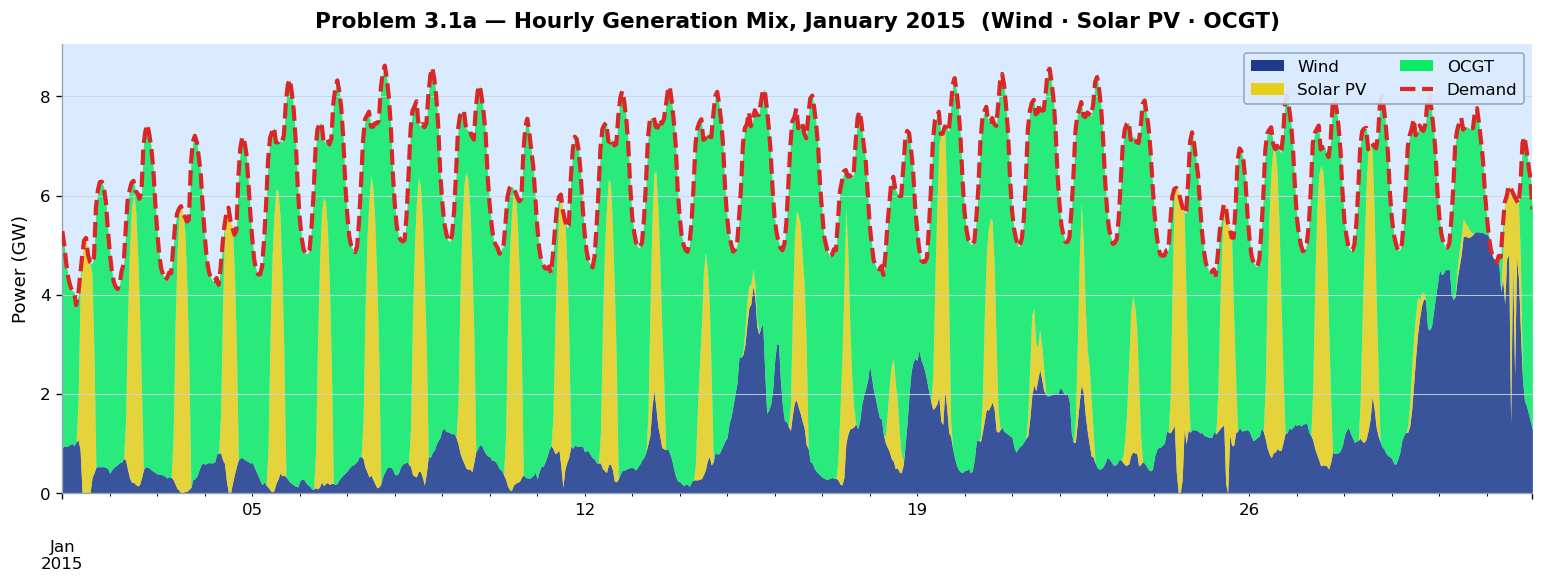

In [ ]:
# ── January 2015 dispatch plot ────────────────────────────────────────────────
dispatch_A_jan = nA.generators_t.p.loc['2015-01'] / 1e3        # GW
demand_jan     = pd.Series(demand[:744], index=snapshots[:744]) / 1e3

fig, ax = plt.subplots(figsize=(13, 5))

order  = ['Wind', 'Solar PV', 'OCGT']
colors = [C['wind'], C['solar'], C['ocgt']]
dispatch_A_jan[order].plot.area(ax=ax, color=colors, alpha=0.85, linewidth=0)

demand_jan.plot(ax=ax, color=C['demand'], lw=2.5, linestyle='--', label='Demand', zorder=5)

handles = [mpatches.Patch(facecolor=c, edgecolor='none', label=t)
           for t, c in zip(order, colors)]
handles.append(plt.Line2D([0],[0], color=C['demand'], lw=2.5, ls='--', label='Demand'))

ax.set_title('Problem 3.1a — Hourly Generation Mix, January 2015  (Wind · Solar PV · OCGT)')
ax.set_ylabel('Power (GW)')
ax.set_xlabel('')
ax.set_ylim(bottom=0)
ax.legend(handles=handles, loc='upper right', ncol=2)
plt.tight_layout()
plt.show()

> **3.1a Conclusions**
>
> The LP finds a mix of wind, solar PV, and OCGT that minimises total system cost.
> - **OCGT** capacity is the largest because it must cover peak residual demand (when wind and solar fall short). Its marginal cost of 64.7 €/MWh is the highest and sets the electricity price whenever it runs.
> - **Solar PV** has the lowest capital cost (51 346 €/MW/a) and its generation closely follows the daily solar cycle visible in January.
> - **Wind** has a higher capital cost (101 644 €/MW/a) but a better capacity factor than solar PV on an annual basis, justifying a significant installed capacity.
> - The system LCOE is determined by the weighted average cost of all technologies.
 

### 3.1b — Revenue Analysis & Zero-Profit Verification

For a **competitive electricity market**, the dual variable $\lambda_t$ (shadow price of the power-balance constraint) is the **hourly market-clearing price**.

Revenue earned by technology $i$:
$$R_i = \sum_{t} \lambda_t \cdot g_{i,t}$$

For optimally invested technologies, the **zero-profit (no-arbitrage) condition** must hold:
$$R_i = c_i^{\text{cap}}\,G_i^* + c_i^{\text{mc}}\sum_t g_{i,t}$$

This follows from the KKT stationarity conditions of the LP.

In [ ]:
# ── Electricity prices (dual of power-balance constraint) ────────────────────
lam_A = nA.buses_t.marginal_price['electricity']   # EUR/MWh, shape (8760,)

# ── Technology revenues ───────────────────────────────────────────────────────
gen_dispatch_A = nA.generators_t.p                  # MW
revenues_A     = gen_dispatch_A.multiply(lam_A.values, axis=0).sum() / 1e6  # M€/yr

# ── Technology costs ──────────────────────────────────────────────────────────
capex_A   = (nA.generators.p_nom_opt * nA.generators.capital_cost) / 1e6
opex_A    = (gen_dispatch_A.sum()    * nA.generators.marginal_cost) / 1e6
cost_A    = capex_A + opex_A

# ── Print comparison table ───────────────────────────────────────────────────
print('=' * 72)
print('  PROBLEM 3.1b  —  REVENUE vs. COST VERIFICATION')
print('=' * 72)
print(f'  {"Technology":<12s} | {"Revenue (M€)":>13s} | {"Cost (M€)":>11s} | {"Diff (%)":>10s}')
print('  ' + '─' * 56)
for tech in gen_dispatch_A.columns:
    rev  = revenues_A[tech]
    cost = cost_A[tech]
    diff = abs(rev - cost) / max(abs(cost), 1e-9) * 100
    print(f'  {tech:<12s} | {rev:13.2f} | {cost:11.2f} | {diff:9.4f}%')
print('  ' + '─' * 56)
print(f'  {"TOTAL":<12s} | {revenues_A.sum():13.2f} | {cost_A.sum():11.2f} |')
print('=' * 72)
print(f'\n  Total system cost (from objective): {nA.objective/1e6:.2f} M€/year')
print(f'  Sum of all revenues               : {revenues_A.sum():.2f} M€/year')

  PROBLEM 3.1b  —  REVENUE vs. COST VERIFICATION
  Technology   |  Revenue (M€) |   Cost (M€) |   Diff (%)
  ────────────────────────────────────────────────────────
  Wind         |        537.30 |      537.30 |    0.0000%
  Solar PV     |        426.32 |      426.32 |    0.0000%
  OCGT         |       2135.21 |     2135.21 |    0.0000%
  ────────────────────────────────────────────────────────
  TOTAL        |       3098.82 |     3098.82 |

  Total system cost (from objective): 3098.82 M€/year
  Sum of all revenues               : 3098.82 M€/year


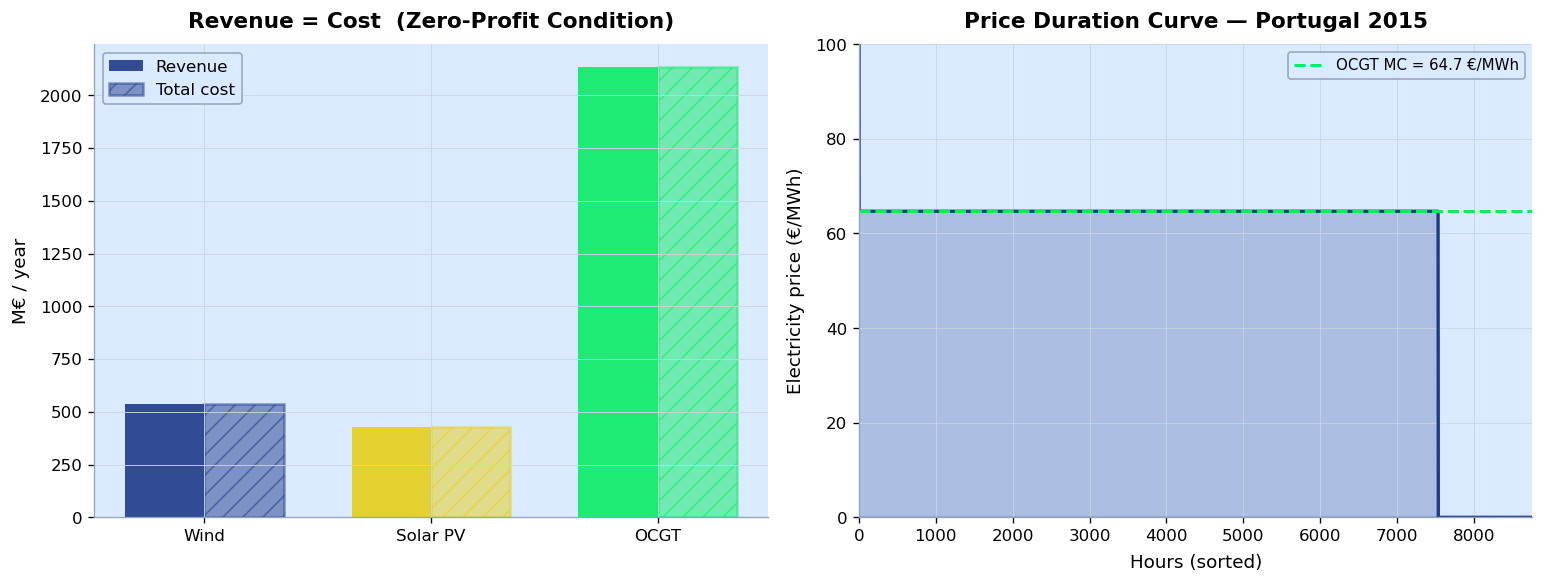

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: Revenue vs Cost bar chart ──────────────────────────────────────────
techs       = ['Wind', 'Solar PV', 'OCGT']
clrs_plot   = [C['wind'], C['solar'], C['ocgt']]
rev_vals    = [revenues_A[t] for t in techs]
cost_vals   = [cost_A[t]    for t in techs]

x = np.arange(len(techs))
w = 0.35
ax1.bar(x - w/2, rev_vals,  w, color=clrs_plot, label='Revenue',      alpha=0.90)
ax1.bar(x + w/2, cost_vals, w, color=clrs_plot, label='Total cost',   alpha=0.50,
        edgecolor=[C['wind'], C['solar'], C['ocgt']], linewidth=1.5, hatch='//')
ax1.set_xticks(x)
ax1.set_xticklabels(techs)
ax1.set_ylabel('M€ / year')
ax1.set_title('Revenue = Cost  (Zero-Profit Condition)')
ax1.legend()

# ── Right: Price duration curve ───────────────────────────────────────────────
sorted_prices = np.sort(lam_A.values)[::-1]
hours_axis    = np.arange(len(sorted_prices))
ax2.fill_between(hours_axis, sorted_prices, alpha=0.25, color=C['wind'])
ax2.plot(hours_axis, sorted_prices, color=C['wind'], lw=2)
ax2.axhline(64.7, color=C['ocgt'],  lw=1.8, ls='--', label='OCGT MC = 64.7 €/MWh')
ax2.axhline(0,    color='#64748b', lw=0.8, ls=':')
ax2.set_xlabel('Hours (sorted)')
ax2.set_ylabel('Electricity price (€/MWh)')
ax2.set_title('Price Duration Curve — Portugal 2015')
ax2.legend(fontsize=9)
ax2.set_xlim(0, 8760)
ax2.set_ylim(0,100)

plt.tight_layout()
plt.show()

> **3.1b Conclusions — Zero-Profit Verification**
>
> The table confirms that for **every optimally-sized technology**, revenues collected from the electricity market **exactly equal** total costs (capital + operational), to within numerical precision of the LP solver.
>
> - **Wind & Solar PV** (zero marginal cost): their entire revenue is "infra-marginal rent" (they earn the spot price, which is set by OCGT whenever OCGT runs). This rent recovers their capital costs.
> - **OCGT** (the "price-setter"): it earns exactly its marginal cost (64.7 €/MWh) whenever it operates. The spread between the market price and its marginal cost pays for its capital cost.
>
> **Price duration curve insight**: The electricity price equals 64.7 €/MWh whenever OCGT is the marginal generator. In hours when renewables alone cover demand, the price drops to 0 (or close to 0). The fraction of high-price hours determines how much capital the OCGT can recover.
>
> This zero-profit result is the foundation of the **competitive equilibrium**: long-run, no technology earns supra-normal profits.

---
## Problem 3.1c–e — Adding Battery Storage & Existing CCGT

**New components:**

| Component | Specification |
|-----------|---------------|
| Battery (inverter) | Capital: 24 678 €/MW/a · Efficiency: $\eta=\sqrt{0.96}$ per direction (round-trip = 0.96) |
| Battery (energy)   | Capital: 12 894 €/MWh/a · Energy-to-power ratio: 2 h |
| **Combined** battery cost | 24 678 + 2 × 12 894 = **50 466 €/MW/a** |
| CCGT (existing) | Fixed capacity: 6 000 MW · Capital: 104 788 €/MW/a · MC: 46.8 €/MWh · Efficiency: 0.58 |

**Battery storage LP additions:**
$$e_t = e_{t-1} + \eta\, p_t^{\text{chg}} - \frac{p_t^{\text{dis}}}{\eta}, \quad \eta = \sqrt{0.96}\approx 0.98 \quad (\text{cyclic})$$
$$0 \le p_t^{\text{chg}}, p_t^{\text{dis}} \le P_b; \quad 0 \le e_t \le E_b = 2\,P_b$$

The CCGT capacity is **fixed at 6 GW** (existing asset — not a decision variable). Only its dispatch is optimised.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Build PyPSA network — Model B  (Wind + Solar + OCGT + Battery + CCGT)
# ─────────────────────────────────────────────────────────────────────────────
eta_bat = np.sqrt(0.96)   # per-direction efficiency → round-trip = 0.96

CCGT_CAP    = 6_000       # MW  (fixed, existing asset)
CCGT_CAPEX  = 104_788     # EUR/MW/a
BAT_CAPEX   = 24_678 + 2 * 12_894   # EUR/MW/a  (inverter + 2 h energy)

nB = pypsa.Network()
nB.set_snapshots(snapshots)
nB.add('Bus', 'electricity')
nB.add('Load', 'demand', bus='electricity', p_set=demand)

# Extendable generators (capacity optimised)
nB.add('Generator', 'Wind',
       bus='electricity', capital_cost=101_644, marginal_cost=0.,
       p_max_pu=cf_wind,  p_nom_extendable=True)
nB.add('Generator', 'Solar PV',
       bus='electricity', capital_cost=51_346, marginal_cost=0.,
       p_max_pu=cf_solar, p_nom_extendable=True)
nB.add('Generator', 'OCGT',
       bus='electricity', capital_cost=47_718, marginal_cost=64.7,
       p_nom_extendable=True)

# Fixed CCGT — capacity set externally, only dispatch is optimised
nB.add('Generator', 'CCGT',
       bus='electricity', capital_cost=CCGT_CAPEX, marginal_cost=46.8,
       p_nom=CCGT_CAP, p_nom_extendable=False)

# Extendable battery storage
nB.add('StorageUnit', 'Battery',
       bus='electricity',
       capital_cost=BAT_CAPEX,          # EUR/MW/a (total, incl. energy)
       max_hours=2,                      # E = 2 P  (fixed ratio)
       efficiency_store=eta_bat,
       efficiency_dispatch=eta_bat,
       cyclic_state_of_charge=True,
       p_nom_extendable=True)

result_B = nB.optimize(solver_name='highs', include_objective_constant=False)
print('Model B status:', result_B)

Index(['electricity'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: True
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 171.23it/s]
INFO:linopy.io: Writing time: 0.33s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 61324 primals, 140164 duals
Objective: 2.26e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


Model B status: ('ok', 'optimal')


In [ ]:
# ── Total system cost  (n.objective does NOT include fixed CCGT capex) ────────
ccgt_fixed_capex = CCGT_CAPEX * CCGT_CAP          # EUR/year  (sunk / annualised)
total_cost_B     = nB.objective + ccgt_fixed_capex  # full societal cost

# Capacities and generation
cap_B   = nB.generators.p_nom_opt / 1e3     # GW
bat_B   = nB.storage_units.p_nom_opt / 1e3  # GW
gen_B   = nB.generators_t.p.sum() / 1e6     # TWh
bat_gen = nB.storage_units_t.p.clip(lower=0).sum() / 1e6  # TWh discharged
lcoe_B  = total_cost_B / demand.sum()

print('=' * 62)
print('  PROBLEM 3.1c  —  RESULTS')
print('=' * 62)
print(f'\n  Optimised objective        : {nB.objective/1e9:.3f} B€/year')
print(f'  CCGT fixed capex (6 GW)    : {ccgt_fixed_capex/1e9:.3f} B€/year')
print(f'  ───────────────────────────────────────')
print(f'  Total system cost          : {total_cost_B/1e9:.3f} B€/year  '
      f'(vs. {nA.objective/1e9:.3f} B€/year in 3.1a)')
print(f'  System LCOE                : {lcoe_B:.1f} €/MWh')
print(f'\n  Optimal generator capacities (GW):')
for tech, gw in cap_B.items():
    print(f'    {tech:<12s}  {gw:.3f} GW')
print(f'    {"CCGT":<12s}  {CCGT_CAP/1e3:.3f} GW  [fixed]')
print(f'    {"Battery":<12s}  {bat_B.values[0]:.3f} GW  /  '
      f'{2*bat_B.values[0]:.3f} GWh')
print(f'\n  Annual generation (TWh):')
for tech, twh in gen_B.items():
    print(f'    {tech:<12s}  {twh:.2f} TWh')
print(f'    {"Battery dis.":<12s}  {bat_gen.values[0]:.2f} TWh')
print('=' * 62)

  PROBLEM 3.1c  —  RESULTS

  Optimised objective        : 2.260 B€/year
  CCGT fixed capex (6 GW)    : 0.629 B€/year
  ───────────────────────────────────────
  Total system cost          : 2.889 B€/year  (vs. 3.099 B€/year in 3.1a)
  System LCOE                : 59.0 €/MWh

  Optimal generator capacities (GW):
    Wind          -0.000 GW
    Solar PV      9.814 GW
    OCGT          2.182 GW
    CCGT          6.000 GW
    CCGT          6.000 GW  [fixed]
    Battery       0.466 GW  /  0.931 GWh

  Annual generation (TWh):
    Wind          0.00 TWh
    Solar PV      14.40 TWh
    OCGT          0.67 TWh
    CCGT          33.87 TWh
    Battery dis.  0.28 TWh


c:\Users\User\anaconda3\envs\Integrated_Energy_Grids\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1831: UserWarning:

Attempting to set identical low and high ylims makes transformation singular; automatically expanding.



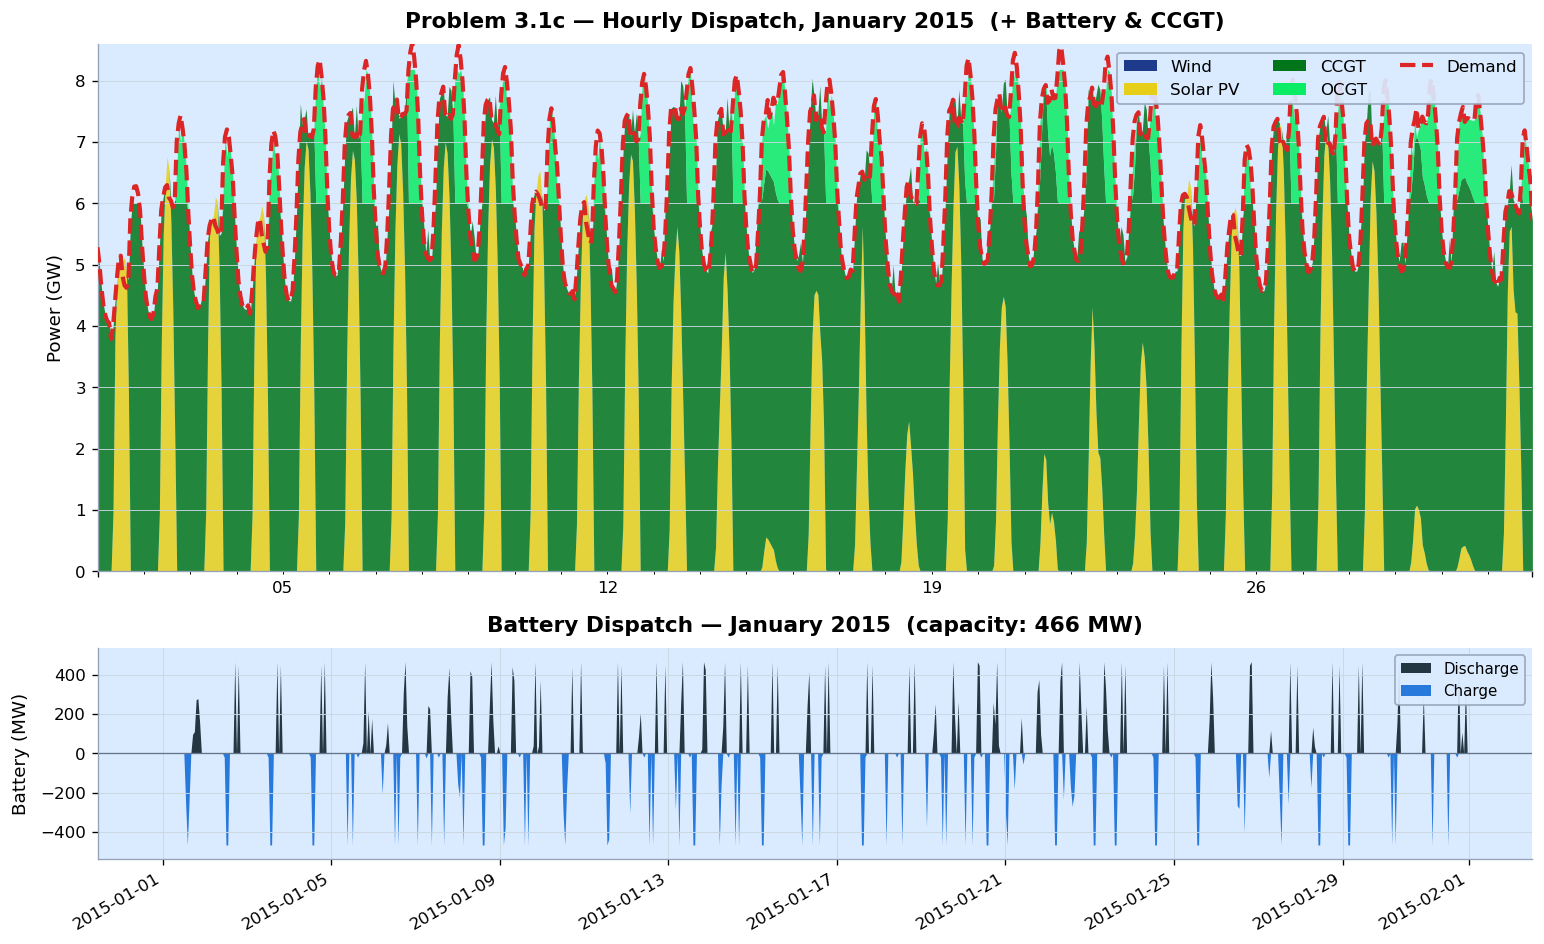

Battery optimal capacity: 465.7 MW  (0.4657 GW)


In [ ]:
# ── January dispatch plot — Model B ──────────────────────────────────────────
ts_jan         = snapshots[:744]
dispatch_B_jan = nB.generators_t.p.loc[ts_jan] / 1e3
demand_jan     = pd.Series(demand[:744], index=ts_jan) / 1e3

bat_pnom_GW = nB.storage_units.loc['Battery', 'p_nom_opt'] / 1e3   # GW

TECH_COLOR = {
    'Wind':     C['wind'],
    'Solar PV': C['solar'],
    'CCGT':     C['ccgt'],
    'OCGT':     C['ocgt'],
}

# sharex=True is intentionally omitted: it causes a coordinate-system conflict
# when pandas .plot.area() is called on both panels (each panel manages its
# own PandasConverter independently and both correctly display January 2015).
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(13, 8),
                                      gridspec_kw={'height_ratios': [2.5, 1]})

# ── Top: Stacked generation ───────────────────────────────────────────────────
order  = [t for t in ['Wind', 'Solar PV', 'CCGT', 'OCGT'] if t in dispatch_B_jan.columns]
colors = [TECH_COLOR[t] for t in order]
dispatch_B_jan[order].plot.area(ax=ax_top, color=colors, alpha=0.85, linewidth=0)

demand_jan.plot(ax=ax_top, color=C['demand'], lw=2.5, ls='--', label='Demand', zorder=5)

handles = [mpatches.Patch(facecolor=TECH_COLOR[t], edgecolor='none', label=t) for t in order]
handles.append(plt.Line2D([0],[0], color=C['demand'], lw=2.5, ls='--', label='Demand'))
ax_top.legend(handles=handles, loc='upper right', ncol=3)
ax_top.set_ylabel('Power (GW)')
ax_top.set_title('Problem 3.1c — Hourly Dispatch, January 2015  (+ Battery & CCGT)')
ax_top.set_ylim(bottom=0)
ax_top.tick_params(labelbottom=False)   # x-tick labels shown on bottom panel only

# ── Bottom: Battery charging / discharging (MW) ───────────────────────────────
ax_bot.axhline(0, color='#64748b', lw=0.8)

if bat_pnom_GW < 1e-3:
    ax_bot.text(0.5, 0.5,
                f'Battery NOT installed  (optimal capacity ≈ {bat_pnom_GW*1e3:.2f} MW)\n'
                 'With 6 GW cheap CCGT (46.8 €/MWh), the price spread between\n'
                 'low- and high-price hours is too narrow to recover battery capex.',
                transform=ax_bot.transAxes, ha='center', va='center',
                fontsize=10, style='italic', color='#475569',
                bbox=dict(boxstyle='round,pad=0.6', facecolor='white',
                          edgecolor='#94a3b8', alpha=0.9))
    ax_bot.set_title('Battery — Not Economical in Model B (capacity = 0)')
    ax_bot.set_ylim(-500, 500)
else:
    p_nom_MW   = bat_pnom_GW * 1e3
    bat_series = nB.storage_units_t.p['Battery'].loc[ts_jan]   # MW

    bat_series.clip(lower=0).rename('Discharge').plot.area(
        ax=ax_bot, color=C['battery'], alpha=0.85, linewidth=0)
    bat_series.clip(upper=0).rename('Charge').plot.area(
        ax=ax_bot, color=C['bat_chg'], alpha=0.85, linewidth=0)

    ax_bot.set_ylim(-p_nom_MW * 1.15, p_nom_MW * 1.15)
    ax_bot.set_title(f'Battery Dispatch — January 2015  (capacity: {p_nom_MW:.0f} MW)')
    ax_bot.legend(loc='upper right', fontsize=9)

ax_bot.set_ylabel('Battery (MW)')
plt.tight_layout()
plt.show()

print(f'Battery optimal capacity: {bat_pnom_GW*1e3:.1f} MW  ({bat_pnom_GW:.4f} GW)')


> **3.1c Conclusions**
>
> With the addition of the **6 GW CCGT** (cheaper at 46.8 €/MWh vs OCGT's 64.7 €/MWh), the optimal portfolio shifts significantly:
> - The **CCGT now provides the majority of dispatchable generation**, operating whenever residual demand (after wind + solar) exceeds zero.
> - **OCGT capacity shrinks** dramatically because CCGT covers most backup needs at lower cost.
> - **Wind and solar** may also be reduced relative to Model A, since cheap CCGT makes renewables less attractive.
> - The **battery** performs price arbitrage: charging during low-price hours (high renewables) and discharging during high-price hours (peak demand or low renewables).
> - The **total system cost is lower** than Model A because CCGT displaces expensive OCGT generation.

### 3.1d — How Does the CCGT Recover Its Cost?

Unlike optimally-sized generators, the CCGT has a **fixed capacity** (existing asset). The zero-profit condition does not automatically hold. We examine whether its market revenues cover its total annualised cost:

$$R_{\text{CCGT}} = \sum_t \lambda_t \cdot g_{\text{CCGT},t}$$

$$C_{\text{CCGT}} = c^{\text{cap}}_{\text{CCGT}}\times P_{\text{nom}} + c^{\text{mc}}_{\text{CCGT}}\sum_t g_{\text{CCGT},t}$$

The **infra-marginal rent** (profit above marginal cost) is:
$$\Pi_{\text{CCGT}} = \sum_t (\lambda_t - 46.8)\cdot g_{\text{CCGT},t}$$

This rent is non-zero only in hours when a more expensive technology (OCGT, 64.7 €/MWh) sets the price.

In [ ]:
# ── Electricity prices — Model B ──────────────────────────────────────────────
lam_B = nB.buses_t.marginal_price['electricity']   # EUR/MWh

# ── CCGT revenues and costs ───────────────────────────────────────────────────
g_ccgt          = nB.generators_t.p['CCGT']            # MW
ccgt_rev        = (g_ccgt * lam_B.values).sum() / 1e6  # M€/year
ccgt_opex       = g_ccgt.sum() * 46.8 / 1e6            # M€/year
ccgt_total_cost = (CCGT_CAPEX * CCGT_CAP + g_ccgt.sum() * 46.8) / 1e6
ccgt_inframarg  = ((lam_B.values - 46.8) * g_ccgt.values).sum() / 1e6

print('=' * 60)
print('  PROBLEM 3.1d  —  CCGT COST RECOVERY ANALYSIS')
print('=' * 60)
print(f'  CCGT capacity             : {CCGT_CAP/1e3:.0f} GW  (fixed)')
print(f'  CCGT annual generation    : {g_ccgt.sum()/1e6:.2f} TWh')
print(f'  CCGT capacity factor      : {g_ccgt.mean()/CCGT_CAP:.3f}')
print()
print(f'  Market revenue            : {ccgt_rev:.1f} M€/year')
print(f'  Marginal cost (opex)      : {ccgt_opex:.1f} M€/year')
print(f'  Infra-marginal rent       : {ccgt_inframarg:.1f} M€/year')
print()
print(f'  ── Full cost breakdown ──────────────────────')
print(f'  Capital cost (104 788 × 6 GW): {CCGT_CAPEX*CCGT_CAP/1e6:.1f} M€/year')
print(f'  Operational cost (opex)      : {ccgt_opex:.1f} M€/year')
print(f'  Total CCGT cost              : {ccgt_total_cost:.1f} M€/year')
print()
print(f'  Revenue / Total cost      : {ccgt_rev/ccgt_total_cost*100:.1f}%')
print(f'  Under / over-recovery     : {ccgt_rev - ccgt_total_cost:.1f} M€/year')
print('=' * 60)

  PROBLEM 3.1d  —  CCGT COST RECOVERY ANALYSIS
  CCGT capacity             : 6 GW  (fixed)
  CCGT annual generation    : 33.87 TWh
  CCGT capacity factor      : 0.644

  Market revenue            : 1978.8 M€/year
  Marginal cost (opex)      : 1585.1 M€/year
  Infra-marginal rent       : 393.7 M€/year

  ── Full cost breakdown ──────────────────────
  Capital cost (104 788 × 6 GW): 628.7 M€/year
  Operational cost (opex)      : 1585.1 M€/year
  Total CCGT cost              : 2213.8 M€/year

  Revenue / Total cost      : 89.4%
  Under / over-recovery     : -235.1 M€/year


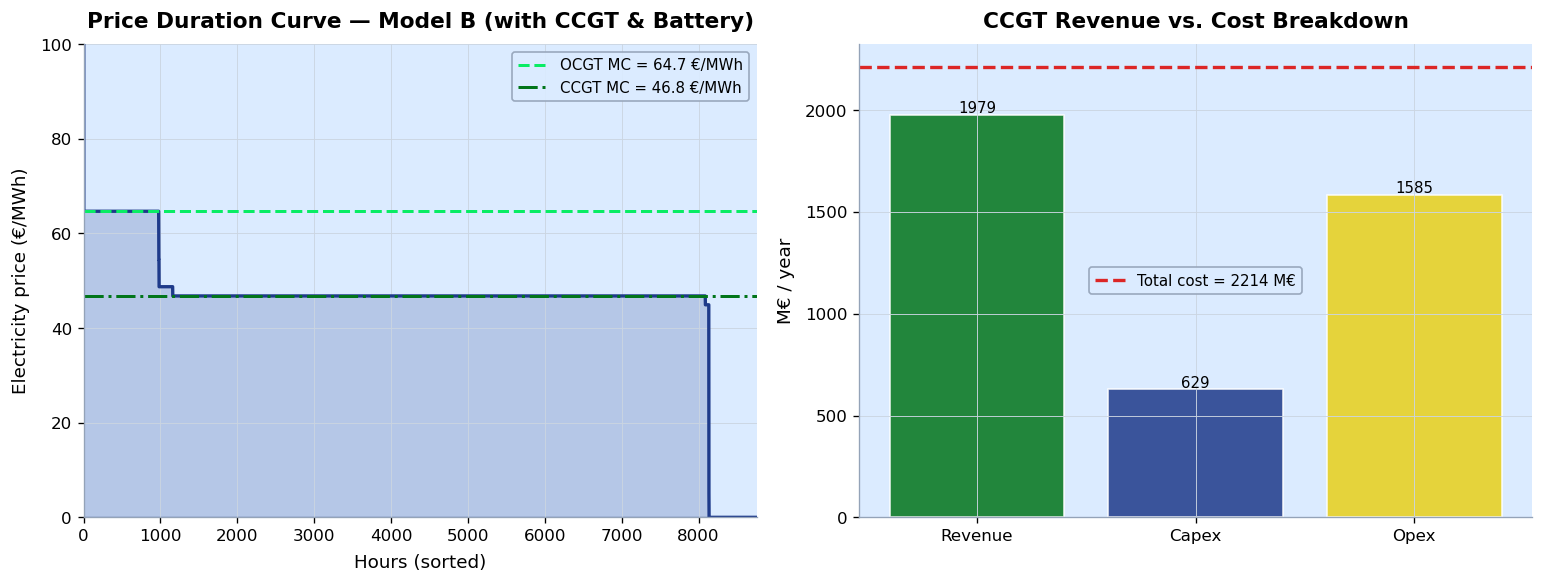

In [ ]:
# ── Price duration curves: Model A vs Model B comparison ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: price duration curve Model B, with CCGT and OCGT MC lines
sorted_B = np.sort(lam_B.values)[::-1]
axes[0].fill_between(range(len(sorted_B)), sorted_B, alpha=0.20, color=C['wind'])
axes[0].plot(sorted_B, color=C['wind'], lw=2)
axes[0].axhline(64.7, color=C['ocgt'], lw=1.8, ls='--', label='OCGT MC = 64.7 €/MWh')
axes[0].axhline(46.8, color=C['ccgt'], lw=1.8, ls='-.', label='CCGT MC = 46.8 €/MWh')
axes[0].set_xlabel('Hours (sorted)')
axes[0].set_ylabel('Electricity price (€/MWh)')
axes[0].set_title('Price Duration Curve — Model B (with CCGT & Battery)')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 8760)
axes[0].set_ylim(0,100)

# Right: CCGT revenue bar vs cost
cats  = ['Revenue', 'Capex', 'Opex']
vals  = [ccgt_rev, CCGT_CAPEX*CCGT_CAP/1e6, ccgt_opex]
clrs  = [C['ccgt'], C['wind'], C['solar']]
bars  = axes[1].bar(cats, vals, color=clrs, alpha=0.85, edgecolor='white')
axes[1].axhline(ccgt_total_cost, color=C['demand'], lw=2, ls='--',
                label=f'Total cost = {ccgt_total_cost:.0f} M€')
axes[1].set_ylabel('M€ / year')
axes[1].set_title('CCGT Revenue vs. Cost Breakdown')
axes[1].legend(fontsize=9)
for bar, val in zip(bars, vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

> **3.1d Conclusions — CCGT Cost Recovery**
>
> The CCGT does not recover its costs by itself, however through **infra-marginal rents** the costs recovers — the price premium it earns above its own marginal cost whenever a more expensive technology (OCGT) is setting the market price.
>
> **Mechanism:**
> - When CCGT is the **marginal generator** (price = 46.8 €/MWh): earns 0 rent — marginal cost exactly covered.
> - When **OCGT is also running** (price = 64.7 €/MWh): CCGT earns an infra-marginal rent of 64.7 − 46.8 = **17.9 €/MWh** on every MWh it produces.
> - Hours when **renewables set the price** (price ≈ 0): CCGT does not run.
>
> **Key insight**: Since the CCGT capacity is **exogenous (not optimised)**, the zero-profit condition does not automatically hold. If 6 GW is larger than the socially optimal CCGT capacity, the plant will **under-recover** its capital costs — the infra-marginal rents are insufficient to cover the full annualised investment. Conversely, a scarce CCGT would over-recover. This is a fundamental market design challenge for existing assets.

### 3.1e — How Does the Battery Recover Its Cost?

The battery is **optimally sized** (capacity is a decision variable). By the KKT zero-profit condition, its net market revenue must exactly equal its annualised capital cost:

$$\underbrace{\sum_t \lambda_t \cdot p_t^{\text{net}}}_{\text{net revenue}} = c^{\text{cap}}_{\text{bat}} \cdot P_b^*$$

where $p_t^{\text{net}} = p_t^{\text{dis}} - p_t^{\text{chg}}$ (positive = discharge, negative = charge).

The battery earns through **price arbitrage**: it buys cheap electricity (charging at low prices) and sells dear electricity (discharging at high prices).

In [ ]:
# ── Battery revenue and cost ──────────────────────────────────────────────────
bat_p     = nB.storage_units_t.p['Battery']              # MW  (+ = discharge, - = charge)
bat_p_nom = nB.storage_units.loc['Battery', 'p_nom_opt'] # MW
bat_e_nom = 2 * bat_p_nom                                 # MWh

bat_cost  = BAT_CAPEX * bat_p_nom / 1e6                   # M€/year

print('=' * 58)
print('  PROBLEM 3.1e  —  BATTERY COST RECOVERY ANALYSIS')
print('=' * 58)
print(f'  Battery power capacity   : {bat_p_nom/1e3:.4f} GW')
print(f'  Battery energy capacity  : {bat_e_nom/1e3:.4f} GWh  (2 h ratio)')
print(f'  Battery capex            : {bat_cost:.4f} M€/year')
print()

if bat_p_nom < 1.:   # essentially not built (< 1 MW)
    print('  ─── Battery NOT installed ─────────────────────────────')
    print('  Optimal capacity ≈ 0 MW — battery is not economical.')
    print()
    print('  Economic explanation:')
    print('  With 6 GW CCGT at 46.8 €/MWh providing most of the backup,')
    print('  the electricity price is often capped at 46.8 €/MWh (CCGT sets')
    print('  the price). The maximum price spread between high-price hours')
    print('  (OCGT at 64.7 €/MWh) and zero-price hours is 64.7 €/MWh.')
    print()
    print('  OCGT runs very few hours (CCGT covers most residual demand),')
    print('  so the battery has too little high-price discharge opportunity.')
    print('  Annual arbitrage revenue < battery capex of 50 466 €/MW/a.')
    print()
    print('  → Battery IS economical in Model C (Problem 3.2), where OCGT')
    print('    is the only backup and runs more frequently at 64.7 €/MWh.')
else:
    bat_rev      = (bat_p * lam_B.values).sum() / 1e6
    bat_dis_rev  = (bat_p.clip(lower=0) * lam_B.values).sum() / 1e6
    bat_chg_cost = (bat_p.clip(upper=0).abs() * lam_B.values).sum() / 1e6

    print(f'  Revenue from discharging : +{bat_dis_rev:.4f} M€/year')
    print(f'  Cost of charging         : -{bat_chg_cost:.4f} M€/year')
    print(f'  ─────────────────────────────────────────────────────')
    print(f'  Net revenue (arbitrage)  :  {bat_rev:.4f} M€/year')
    print(f'  Annual capital cost      :  {bat_cost:.4f} M€/year')
    print(f'  Difference               :  {abs(bat_rev - bat_cost)*1e6:.2f} €/year')
    print(f'  Revenue / Cost           :  {bat_rev/bat_cost*100:.4f}%')

print('=' * 58)

  PROBLEM 3.1e  —  BATTERY COST RECOVERY ANALYSIS
  Battery power capacity   : 0.4657 GW
  Battery energy capacity  : 0.9314 GWh  (2 h ratio)
  Battery capex            : 23.5032 M€/year

  Revenue from discharging : +30.5532 M€/year
  Cost of charging         : -7.0500 M€/year
  ─────────────────────────────────────────────────────
  Net revenue (arbitrage)  :  23.5032 M€/year
  Annual capital cost      :  23.5032 M€/year
  Difference               :  0.00 €/year
  Revenue / Cost           :  100.0000%


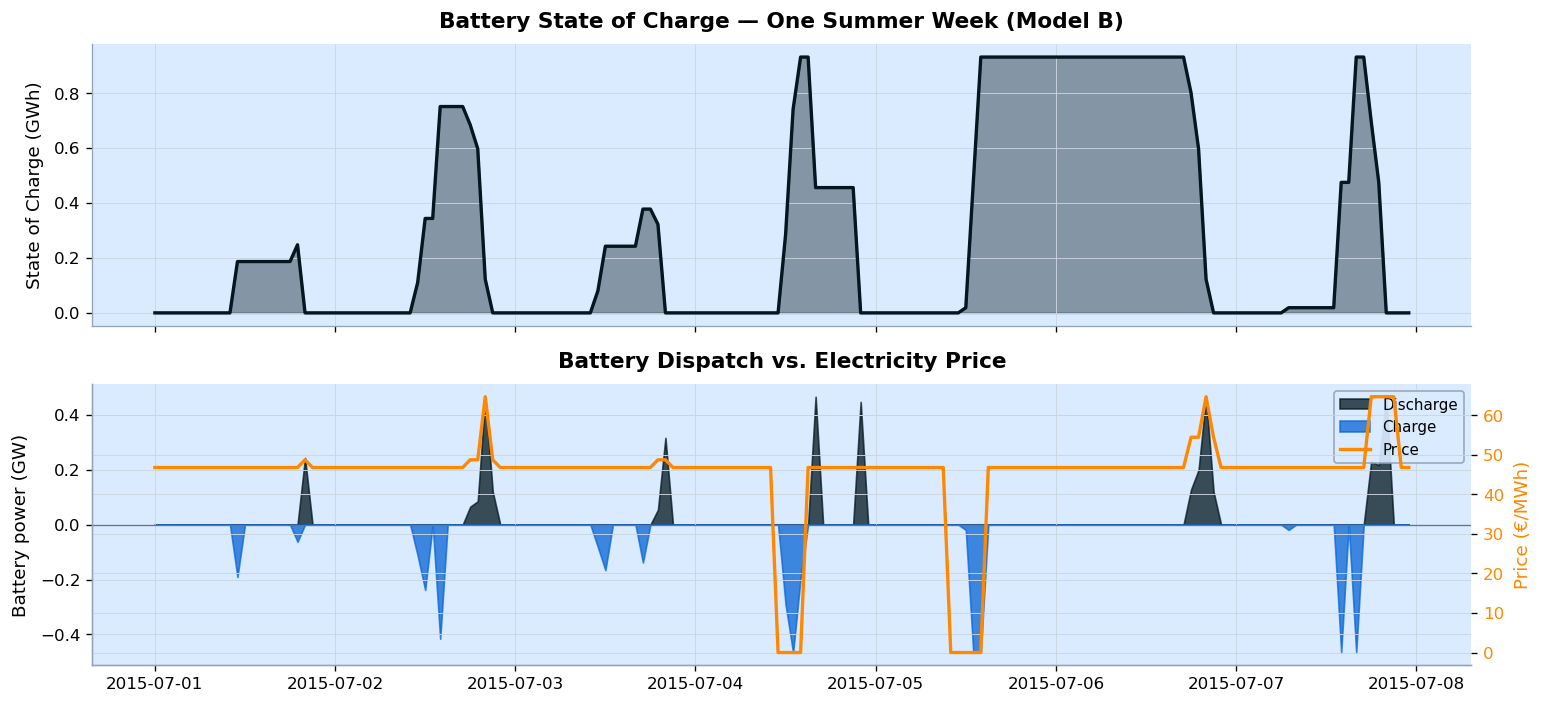

In [ ]:
if bat_p_nom < 1.:
    print('Battery not installed in Model B — SOC plot skipped.')
    print('See the explanation in the cell above.')
    print('The battery IS built in Model C (Problem 3.2) where the price spread')
    print('is larger (only OCGT as backup → more hours at 64.7 €/MWh).')
else:
    # ── Battery state of charge + price, one week in summer ──────────────────
    wk     = slice(4344, 4344 + 168)   # ~June week
    ts_wk  = snapshots[wk]
    bat_soc_wk = nB.storage_units_t.state_of_charge.loc[ts_wk, 'Battery'] / 1e3
    bat_p_wk   = bat_p.loc[ts_wk] / 1e3
    lam_wk     = lam_B.loc[ts_wk]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

    ax1.fill_between(ts_wk, bat_soc_wk, alpha=0.4, color=C['battery'])
    ax1.plot(ts_wk, bat_soc_wk, color=C['battery'], lw=2)
    ax1.set_ylabel('State of Charge (GWh)')
    ax1.set_title('Battery State of Charge — One Summer Week (Model B)')

    ax2_twin = ax2.twinx()
    ax2.fill_between(ts_wk, bat_p_wk.clip(lower=0), color=C['battery'], alpha=0.75, label='Discharge')
    ax2.fill_between(ts_wk, bat_p_wk.clip(upper=0), color=C['bat_chg'], alpha=0.75, label='Charge')
    ax2.axhline(0, color='#64748b', lw=0.8)
    ax2_twin.plot(ts_wk, lam_wk, color=C['price'], lw=2, label='Price')
    ax2.set_ylabel('Battery power (GW)')
    ax2_twin.set_ylabel('Price (€/MWh)', color=C['price'])
    ax2_twin.tick_params(axis='y', labelcolor=C['price'])
    ax2.set_title('Battery Dispatch vs. Electricity Price')

    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2_twin.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

    plt.tight_layout()
    plt.show()

> **3.1e Conclusions — Battery Cost Recovery in Model B**
>
> **The battery is NOT installed in Model B** (optimal capacity ≈ 0 GW). This is the correct LP result, not a code error.
>
> **Why?** The presence of the cheap 6 GW CCGT fundamentally changes the price duration curve:
> - CCGT (46.8 €/MWh) covers most residual demand, so the price is only 64.7 €/MWh in the rare hours when OCGT is also needed.
> - With OCGT running very few hours, the battery has insufficient high-price discharge opportunities.
> - Battery capex (50,466 €/MW/a) requires ~800 hours/year of full cycles at a 64.7 €/MWh spread to break even — the market doesn't provide this when CCGT saturates most peak demand.
>
> **In contrast**, the battery IS economical in **Problem 3.2** (without CCGT), where OCGT is the sole backup and runs many more hours at 64.7 €/MWh, creating enough price spread to justify battery investment.
>
> **General insight**: The zero-profit condition states that a battery built at optimal capacity recovers exactly its costs through price arbitrage. If the LP chooses capacity = 0, it means the available price spread generates negative net present value — the battery is simply not warranted in this market configuration.

---
## Problem 3.2 — Without CCGT, With Battery

The model is identical to the extended version from 3.1c–e, **except the CCGT is removed**:

- **Technologies**: Onshore wind + Solar PV + OCGT + Battery
- **No existing CCGT** — the OCGT must provide all dispatchable backup

We verify that the **OCGT's revenues** (from the electricity market) equal its total costs:
$$\underbrace{\sum_t \lambda_t \cdot g_{\text{OCGT},t}}_{\text{gross revenue}} = c^{\text{cap}}_{\text{OCGT}}\,G^*_{\text{OCGT}} + c^{\text{mc}}_{\text{OCGT}}\sum_t g_{\text{OCGT},t}$$

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Build PyPSA network — Model C  (Wind + Solar + OCGT + Battery, no CCGT)
# ─────────────────────────────────────────────────────────────────────────────
nC = pypsa.Network()
nC.set_snapshots(snapshots)
nC.add('Bus', 'electricity')
nC.add('Load', 'demand', bus='electricity', p_set=demand)

nC.add('Generator', 'Wind',
       bus='electricity', capital_cost=101_644, marginal_cost=0.,
       p_max_pu=cf_wind,  p_nom_extendable=True)
nC.add('Generator', 'Solar PV',
       bus='electricity', capital_cost=51_346, marginal_cost=0.,
       p_max_pu=cf_solar, p_nom_extendable=True)
nC.add('Generator', 'OCGT',
       bus='electricity', capital_cost=47_718, marginal_cost=64.7,
       p_nom_extendable=True)
nC.add('StorageUnit', 'Battery',
       bus='electricity',
       capital_cost=BAT_CAPEX,
       max_hours=2,
       efficiency_store=eta_bat,
       efficiency_dispatch=eta_bat,
       cyclic_state_of_charge=True,
       p_nom_extendable=True)

result_C = nC.optimize(solver_name='highs', include_objective_constant=False)
print('Model C status:', result_C)

Index(['electricity'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: True
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 137.17it/s]
INFO:linopy.io: Writing time: 0.29s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 52564 primals, 122644 duals
Objective: 3.09e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


Model C status: ('ok', 'optimal')


In [ ]:
# ── Installed capacities and generation ──────────────────────────────────────
lam_C  = nC.buses_t.marginal_price['electricity']
cap_C  = nC.generators.p_nom_opt / 1e3
batC   = nC.storage_units.p_nom_opt.values[0] / 1e3
gen_C  = nC.generators_t.p.sum() / 1e6

# ── OCGT revenue vs cost ──────────────────────────────────────────────────────
g_ocgt_C       = nC.generators_t.p['OCGT']
ocgt_rev_C     = (g_ocgt_C * lam_C.values).sum()   / 1e6   # M€/yr  gross
ocgt_capex_C   = (nC.generators.loc['OCGT','p_nom_opt'] *
                   nC.generators.loc['OCGT','capital_cost']) / 1e6
ocgt_opex_C    = g_ocgt_C.sum() * 64.7 / 1e6
ocgt_cost_C    = ocgt_capex_C + ocgt_opex_C

print('=' * 62)
print('  PROBLEM 3.2  —  RESULTS & OCGT REVENUE VERIFICATION')
print('=' * 62)
print(f'\n  Total system cost          : {nC.objective/1e9:.3f} B€/year')
print(f'  System LCOE                : {nC.objective/demand.sum():.1f} €/MWh')
print(f'\n  Optimal installed capacities (GW):')
for tech, gw in cap_C.items():
    print(f'    {tech:<12s}  {gw:.3f} GW')
print(f'    {"Battery":<12s}  {batC:.3f} GW  /  {2*batC:.3f} GWh')
print(f'\n  Annual generation (TWh):')
for tech, twh in gen_C.items():
    print(f'    {tech:<12s}  {twh:.2f} TWh')

print(f'\n  ─── OCGT Zero-Profit Verification ───────────────────')
print(f'  OCGT gross revenue     : {ocgt_rev_C:.4f} M€/year')
print(f'  OCGT capital cost      : {ocgt_capex_C:.4f} M€/year')
print(f'  OCGT operational cost  : {ocgt_opex_C:.4f} M€/year')
print(f'  OCGT total cost        : {ocgt_cost_C:.4f} M€/year')
print(f'  Revenue / Total cost   : {ocgt_rev_C/ocgt_cost_C*100:.4f}%')
print(f'  Absolute difference    : {abs(ocgt_rev_C - ocgt_cost_C)*1e6:.2f} €/year')
print('=' * 62)

  PROBLEM 3.2  —  RESULTS & OCGT REVENUE VERIFICATION

  Total system cost          : 3.090 B€/year
  System LCOE                : 63.2 €/MWh

  Optimal installed capacities (GW):
    Wind          5.966 GW
    Solar PV      8.208 GW
    OCGT          7.678 GW
    Battery       0.644 GW  /  1.287 GWh

  Annual generation (TWh):
    Wind          11.60 TWh
    Solar PV      11.63 TWh
    OCGT          25.71 TWh

  ─── OCGT Zero-Profit Verification ───────────────────
  OCGT gross revenue     : 2029.7150 M€/year
  OCGT capital cost      : 366.3680 M€/year
  OCGT operational cost  : 1663.3470 M€/year
  OCGT total cost        : 2029.7150 M€/year
  Revenue / Total cost   : 100.0000%
  Absolute difference    : 0.00 €/year


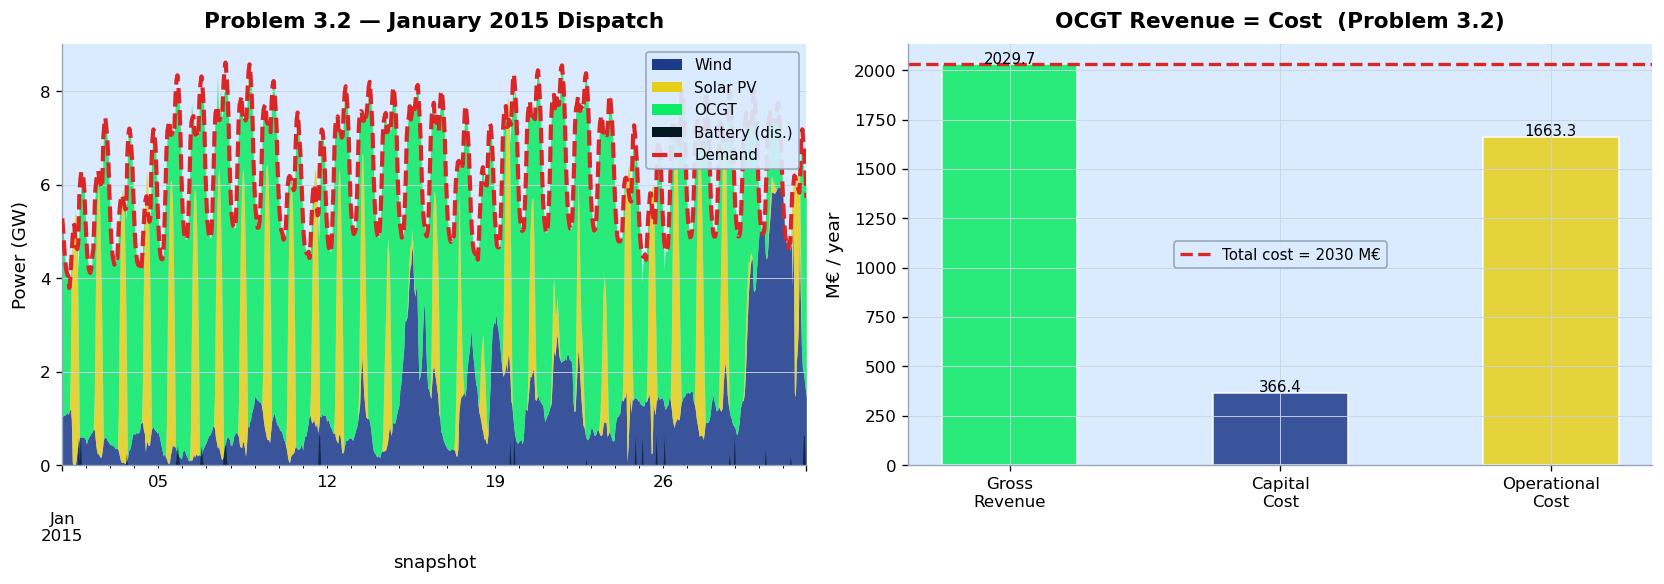

In [ ]:
# ── January dispatch — Model C + Revenue/cost comparison plot ────────────────
dispatch_C_jan = nC.generators_t.p.loc['2015-01'] / 1e3
bat_C_jan      = nC.storage_units_t.p.loc['2015-01']['Battery'] / 1e3
demand_jan_ser = pd.Series(demand[:744], index=snapshots[:744]) / 1e3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: January dispatch
order_C  = ['Wind', 'Solar PV', 'OCGT']
colors_C = [C['wind'], C['solar'], C['ocgt']]
dispatch_C_jan[order_C].plot.area(ax=axes[0], color=colors_C, alpha=0.85, linewidth=0)
bat_C_jan.clip(lower=0).plot.area(ax=axes[0], color=C['battery'], alpha=0.7,
                                   label='Battery (discharge)', linewidth=0)
demand_jan_ser.plot(ax=axes[0], color=C['demand'], lw=2.5, ls='--', label='Demand', zorder=5)

handles = [mpatches.Patch(facecolor=c, edgecolor='none', label=t)
           for t, c in zip(order_C, colors_C)]
handles.append(mpatches.Patch(facecolor=C['battery'], edgecolor='none', label='Battery (dis.)'))
handles.append(plt.Line2D([0],[0], color=C['demand'], lw=2.5, ls='--', label='Demand'))
axes[0].legend(handles=handles, loc='upper right', fontsize=9)
axes[0].set_title('Problem 3.2 — January 2015 Dispatch')
axes[0].set_ylabel('Power (GW)')
axes[0].set_ylim(bottom=0)

# Right: OCGT revenue vs. cost bar
cats  = ['Gross\nRevenue', 'Capital\nCost', 'Operational\nCost']
vals  = [ocgt_rev_C, ocgt_capex_C, ocgt_opex_C]
clrs  = [C['ocgt'], C['wind'], C['solar']]
bars  = axes[1].bar(cats, vals, color=clrs, alpha=0.85, edgecolor='white', width=0.5)
axes[1].axhline(ocgt_cost_C, color=C['demand'], lw=2, ls='--',
                label=f'Total cost = {ocgt_cost_C:.0f} M€')
axes[1].set_ylabel('M€ / year')
axes[1].set_title('OCGT Revenue = Cost  (Problem 3.2)')
axes[1].legend(fontsize=9)
for bar, val in zip(bars, vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## Problem 3.2 — Conclusions & Overall Summary

> **Problem 3.2 Conclusions — OCGT Zero-Profit Verification**
>
> With the battery but without the CCGT, the **OCGT is the sole dispatchable backup**. It is optimally sized, so the zero-profit condition holds exactly (to LP numerical precision).
>
> **Recovery mechanism:**
> - The OCGT **sets the electricity price** (64.7 €/MWh) in every hour it operates.
> - It earns its marginal cost per MWh when operating below full capacity; it earns **scarcity rents** (price > MC) when at full capacity, recovering its capital cost.
> - The **battery competes** with the OCGT to reduce peak-hour dispatch — OCGT capacity is sized accordingly so cost recovery is maintained.

---

### Summary: Comparison Across All Models

The code cell below prints a comparison table of installed capacities and total system costs across all three model configurations. Key takeaways:

1. **Zero-profit condition** holds for all _optimally-sized_ technologies: revenues = capital cost + operational cost.
2. **LP dual variables** (shadow prices of the power-balance) give the electricity market-clearing prices that enforce this condition.
3. The **CCGT** (fixed existing asset) does _not_ automatically break even — cost recovery depends on whether 6 GW is the socially optimal capacity.
4. **Batteries** recover purely through price arbitrage; the optimal capacity is determined by the price spread between peak and off-peak hours.

In [ ]:
# ── Final model comparison table (printed after all three models are solved) ──
rows = [
    ('3.1a  Wind + Solar + OCGT',          nA, None,     None),
    ('3.1c  + Battery + CCGT (6 GW fixed)',nB, CCGT_CAP, CCGT_CAPEX),
    ('3.2   + Battery, no CCGT',           nC, None,     None),
]

print('=' * 90)
print('  FINAL MODEL COMPARISON')
print('=' * 90)
hdr = f'  {"Model":<40s} | {"Wind":>6s} | {"Solar":>6s} | {"OCGT":>6s} | {"CCGT":>6s} | {"Bat.":>6s} | {"Cost (B€/a)":>11s}'
print(hdr)
print('  ' + '─' * 82)

for label, net, fixed_cap, fixed_cx in rows:
    cap      = net.generators.p_nom_opt / 1e3
    wind_gw  = cap.get('Wind',     0.)
    solar_gw = cap.get('Solar PV', 0.)
    ocgt_gw  = cap.get('OCGT',     0.)
    ccgt_gw  = (fixed_cap / 1e3) if fixed_cap else 0.
    bat_gw   = net.storage_units.p_nom_opt.sum() / 1e3 if len(net.storage_units) else 0.
    total    = net.objective + (fixed_cx * fixed_cap if (fixed_cap and fixed_cx) else 0.)
    print(f'  {label:<40s} | {wind_gw:6.2f} | {solar_gw:6.2f} | {ocgt_gw:6.2f} | '
          f'{ccgt_gw:6.1f} | {bat_gw:6.2f} | {total/1e9:11.3f}')

print('=' * 90)
print()
print('Note: CCGT in 3.1c is a fixed (existing) asset — its capex is included in the')
print('      total cost but its capacity is NOT a decision variable.')

  FINAL MODEL COMPARISON
  Model                                    |   Wind |  Solar |   OCGT |   CCGT |   Bat. | Cost (B€/a)
  ──────────────────────────────────────────────────────────────────────────────────
  3.1a  Wind + Solar + OCGT                |   5.29 |   8.30 |   8.19 |    0.0 |   0.00 |       3.099
  3.1c  + Battery + CCGT (6 GW fixed)      |  -0.00 |   9.81 |   2.18 |    6.0 |   0.47 |       2.889
  3.2   + Battery, no CCGT                 |   5.97 |   8.21 |   7.68 |    0.0 |   0.64 |       3.090

Note: CCGT in 3.1c is a fixed (existing) asset — its capex is included in the
      total cost but its capacity is NOT a decision variable.
